In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

import nltk
from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.corpus import wordnet

In [4]:
nltk.download('wordnet')
nltk.download("punkt")
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package wordnet to /Users/pouniq/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /Users/pouniq/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/pouniq/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [ ]:
# !wget -nc https://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv

--2026-08-17 21:28:48--  https://lazyprogrammer.me/course_files/nlp/bbc_text_cls.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 188.114.99.0, 188.114.98.0
Connecting to lazyprogrammer.me (lazyprogrammer.me)|188.114.99.0|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5085081 (4.8M) [text/csv]
Saving to: ‘bbc_text_cls.csv’

bbc_text_cls.csv    100%[===================>]   4.85M  2.87MB/s    in 1.7s    

2026-08-17 21:28:51 (2.87 MB/s) - ‘bbc_text_cls.csv’ saved [5085081/5085081]



In [7]:
df = pd.read_csv('bbc_text_cls.csv')
df

,text,labels
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business
...,...,...
2220,BT program to beat dialler scams\n\nBT is intr...,tech
2221,Spam e-mails tempt net shoppers\n\nComputer us...,tech
2222,Be careful how you code\n\nA new European dire...,tech
2223,US cyber security chief resigns\n\nThe man mak...,tech


In [8]:
df['labels'].unique()

<StringArray>
['business', 'entertainment', 'politics', 'sport', 'tech']
Length: 5, dtype: str

In [10]:
df['text'].iloc[1]

'Dollar gains on Greenspan speech\n\nThe dollar has hit its highest level against the euro in almost three months after the Federal Reserve head said the US trade deficit is set to stabilise.\n\nAnd Alan Greenspan highlighted the US government\'s willingness to curb spending and rising household savings as factors which may help to reduce it. In late trading in New York, the dollar reached $1.2871 against the euro, from $1.2974 on Thursday. Market concerns about the deficit has hit the greenback in recent months. On Friday, Federal Reserve chairman Mr Greenspan\'s speech in London ahead of the meeting of G7 finance ministers sent the dollar higher after it had earlier tumbled on the back of worse-than-expected US jobs data. "I think the chairman\'s taking a much more sanguine view on the current account deficit than he\'s taken for some time," said Robert Sinche, head of currency strategy at Bank of America in New York. "He\'s taking a longer-term view, laying out a set of conditions u

In [11]:
inputs = df['text']
labels = df['labels']

### checking classes imbalance:
it is okay actually and evenly spread out.


<Axes: >

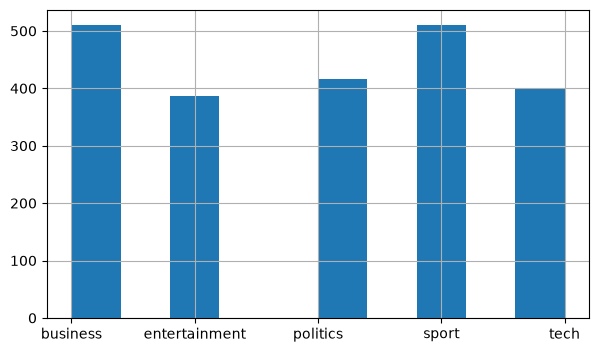

In [15]:
labels.hist(figsize=(7,4))

In [16]:
inputs_train, inputs_test, Ytrain, Ytest = train_test_split(inputs, labels, random_state=42)

In [19]:
vectorizer = CountVectorizer()

In [20]:
X_train = vectorizer.fit_transform(inputs_train)
X_test = vectorizer.transform(inputs_test)

In [21]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 337538 stored elements and shape (1668, 26157)>

- it is a sparse metrices meaning most the items in the matrices is actually zero, to make the matrices more **efficient** because of that our `X_train` is a Sparse Metrices

- one other thing we can notice is the dimensionality of the said matrices, it is 1668 rows by 26157 columns and it is actually what we don't want in Machine Learning, BUT in this case we can say we can ignore that. because it is a **Sparse** metrices.
we check this out in the following code:


In [23]:
(X_train != 0).sum()

np.int64(337538)

In [26]:
# what percentage of values are NON-ZERO ?
# less than 1 percent of values are non-zero
(X_train != 0).sum() / np.prod(X_train.shape)

np.float64(0.00773639604201488)

In [28]:
model = MultinomialNB()
model.fit(X_train, Ytrain)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](5,)","[368.,292.,322.,389.,297.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](5,)","[-1.51,-1.74,-1.64,-1.46,-1.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U13](5,)","['business','entertainment','politics','sport','tech']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](5, 26157)","[[ 0.,179., 0.,..., 0., 0., 0.], [ 1.,111., 0.,..., 1., 0., 1.], [ 2.,149., 1.,..., 0., 0., 0.], [ 2., 22., 0.,..., 0., 4., 0.], [ 1.,161., 0.,..., 0., 0., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](5, 26157)","[[-11.89, -6.7 ,-11.89,...,-11.89,-11.89,-11.89], [-11.01, -6.98,-11.7 ,...,-11.01,-11.7 ,-11.01], [-10.95, -7.03,-11.35,...,-12.04,-12.04,-12.04], [-10.82, -8.78,-11.92,...,-11.92,-10.31,-11.92], [-11.36, -6.97,-12.05,...,-12.05,-12.05,-12.05]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,26157


In [31]:
round(model.score(X_train, Ytrain), 3)

0.995

In [32]:
round(model.score(X_test, Ytest), 3)

0.971

In [ ]:
# fit model with stopwords in place
vec = CountVectorizer(stop_words='english')
X_train = vec.fit_transform(inputs_train)
X_test = vec.transform(inputs_test)
model = MultinomialNB()
model.fit(X_train, Ytrain)
print(model.score(X_train, Ytrain))
print(model.score(X_test, Ytest))


0.9964028776978417
0.9712746858168761
